# Drift sweep — one district at a time, at several strengths

Grid: **network** x **which district drifts** x **drift strength**. The initial map is
all residential, so in the final phase exactly one district differs from the rest and every
regime statistic has a real contrast to resolve.

Three questions it is built to answer.

**(a) Which gauges carry the signal, per network.** Two different answers, both needed:
gauges that *resemble* their district (a property of the network and the placement, scored
in the drift-free phase and averaged over the whole grid) and gauges that *respond* when
their own district is the one drifting (scored only in the cells where that happens).

**(b) Does the shape model carry the drift, or is detection reading a level change.** The
beta ladder. `beta = 0` is volume-neutral — the signature changes and the volume does not.
If detection needs `beta >= 0.6`, the detector is reading level and the consumption
attribution needs work rather than the sensors.

**(c) How much of the response is contamination.** The leak matrix: drift district on the
rows, where the response was measured on the columns. Off-diagonal is hydraulic coupling
arriving through shared pipes.

Engines: `landuse_sweep.py` on top of `landuse_world.py` + `signal_probe.py`. The drift
engine and the FL stack are still untouched.

## 0. Setup

In [1]:
%matplotlib inline
import sys, warnings, pathlib
import numpy as np, pandas as pd, matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 220, "display.max_columns", 80, "display.max_rows", 200)

HERE = pathlib.Path.cwd()
ROOT = next(p for p in [HERE, *HERE.parents] if (p / "conf" / "base").exists())
for p in (HERE, ROOT / "src", ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import landuse_world as lw
import signal_probe as sp
import landuse_sweep as ls

OUT = ROOT / "data" / "09_experiments" / "landuse_sweep"
OUT.mkdir(parents=True, exist_ok=True)
print(ROOT)

c:\Users\arthu\USPy\10_Mestrado\fedWater


## 1. The grid

**Strength axis is `beta`, not income.** `level_factor = (intensity_ratio) ** beta`, and for
residential → industrial at low income the ratio is 9.19:

| beta | 0.00 | 0.15 | 0.35 | 0.60 | 1.00 |
|---|---|---|---|---|---|
| level | 1.00 | 1.39 | 2.17 | 3.78 | 9.19 |

`to_income` cannot do this. Income enters only through the residential plot intensity and
an industrial block is 20% residential by plot share, so the same ratio is 9.19 at low
income, 9.37 at medium and 9.70 at high — a 5% move against beta's 9x. Income would be the
right knob for a residential→residential level drift; that is a different experiment.

beta is global, but with an all-residential initial map every non-drifting district sits at
ratio 1.0 and therefore level_factor 1.0 for any beta. In this design beta moves the
drifting district alone. That stops being true the moment a second non-residential district
is in the initial map.

**Horizon is cut for cost.** 16 months of 14-day months is 5 376 steps against the POC's
33 600. `max_neighbors_per_month` is raised to 8 so the diffusion front finishes early
enough to leave a clean final phase inside that horizon — a change to the front's *width*,
not to the drift mechanism.

In [2]:
CFG = ls.SweepCfg(
    networks=("ky7", "dtown"),
    betas=(0.0, 0.15, 0.35, 0.6, 1.0),
    districts=None,                    # None = every district of every network
    to_land_use="industrial", to_income="low",
    n_months=42, days_per_month=14, warmup_months=2,
    max_neighbors_per_month=8, growth_chance=1.0,
    drift_ramp_days=7, seasonality_scale=0.0)

grid = ls.cells(CFG, ROOT)
print(f"{len(grid)} cells:",
      pd.Series([g.network for g in grid]).value_counts().to_dict())
print("KY7 districts  :", ls.district_names(ROOT, "ky7"))
print("D-Town districts:", ls.district_names(ROOT, "dtown"))
print("\nrough cost: KY7 ~30 s/cell, D-Town ~150 s/cell at this horizon.")

45 cells: {'dtown': 25, 'ky7': 20}
KY7 districts  : ['District_A', 'District_B', 'District_C', 'District_D']
D-Town districts: ['District_A', 'District_B', 'District_C', 'District_D', 'District_E']

rough cost: KY7 ~30 s/cell, D-Town ~150 s/cell at this horizon.


## 2. Run

Cells are content-addressed by `sim_hash` and cached, so an interrupted sweep resumes and a
widened grid only pays for the new cells. A cell that fails — usually V3, the pressure
floor, at high beta — is recorded with its error and the sweep continues: an infeasible
corner is a result about the network's capacity, not a reason to lose the grid.

In [ ]:
CELLS, SCORES, DELTAS = ls.run_sweep(CFG, ROOT, OUT, cache=True, phase="final")

In [4]:
print(CELLS.groupby(["network", "status"]).size().to_string())
display(CELLS[CELLS["status"] != "ok"][["network", "drift_district", "beta", "error"]])
CELLS[CELLS["status"] == "ok"].groupby("network")[
    ["d_demand_%", "shape_shift", "d_pressure", "seconds"]].describe().round(2).T

network  status
dtown    fail      10
         ok        15
ky7      fail       4
         ok        16


,network,drift_district,beta,error
4,ky7,District_A,1.0,AssertionError: V3 pressure floor violated: no...
9,ky7,District_B,1.0,AssertionError: V3 pressure floor violated: no...
13,ky7,District_C,0.6,AssertionError: V3 pressure floor violated: no...
14,ky7,District_C,1.0,AssertionError: V1 mass balance violated: rel_...
23,dtown,District_A,0.6,AssertionError: V3 pressure floor violated: no...
24,dtown,District_A,1.0,AssertionError: V3 pressure floor violated: no...
28,dtown,District_B,0.6,AssertionError: V3 pressure floor violated: no...
29,dtown,District_B,1.0,AssertionError: V3 pressure floor violated: no...
33,dtown,District_C,0.6,AssertionError: V3 pressure floor violated: no...
34,dtown,District_C,1.0,AssertionError: V1 mass balance violated: rel_...


network             dtown     ky7
d_demand_%  count   15.00   16.00
            mean    52.26  142.42
            std     50.46  205.72
            min     -0.44   -0.35
            25%      0.34   28.74
            50%     39.43   76.67
            75%    116.61  158.47
            max    118.27  815.11
shape_shift count   15.00   16.00
            mean     0.73    0.71
            std      0.00    0.04
            min      0.72    0.59
            25%      0.72    0.71
            50%      0.72    0.72
            75%      0.73    0.72
            max      0.73    0.73
d_pressure  count   15.00   16.00
            mean    -0.18   -0.01
            std      0.71    0.45
            min     -1.74   -1.24
            25%     -0.38   -0.00
            50%     -0.02    0.15
            75%      0.14    0.26
            max      0.92    0.39
seconds     count   15.00   16.00
            mean   164.74   73.76
            std     20.98   16.51
            min    135.90   53.50
            25%    151.05   60.30
            50%    158.20   74.10
            75%    181.10   80.65
            max    203.50  104.00

Where the sweep fails is informative on its own. D-Town's anchor sits at 0.25 against a
cliff measured between 0.35 and 0.50, so a district converting to industrial at `beta = 1.0`
(9.2x its own level) is a real capacity question, not a bug. If whole districts fail at
high beta, that is the network saying the drift magnitude the detector wants is outside its
hydraulic envelope — which would itself be an argument for making the *shape* carry the
signal instead of the level.

## 3. The beta ladder — does shape alone carry the drift?

`resp_flow_top` is the mean response of the drifting district's three best-resembling flow
gauges: the correlation between how the gauge's weekly signature moved and how the
district's demand signature moved. It is computed on z-scored profiles, so a pure level
change scores 0 — the number only moves if the *shape* moved.

Read the ladder bottom-up. High response already at `beta = 0` means the sector signature
alone is legible and the attribution protocol is fine. Response that only appears at
`beta >= 0.6` means the detector is reading volume.

,network,drift_district,beta,d_demand_%,shape_shift,d_pressure,gap_flow,gap_pressure,resp_flow_top,resp_pressure_top,resp_leak_p95,status
0,dtown,District_A,0.00,0.254,0.724,0.230,0.953,0.661,1.000,0.989,0.708,ok
1,dtown,District_A,0.15,39.827,0.724,0.007,1.042,0.593,1.000,0.989,0.708,ok
2,dtown,District_A,0.35,117.879,0.725,-0.428,1.029,0.638,1.000,0.989,0.708,ok
3,dtown,District_A,0.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fail
4,dtown,District_A,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fail
5,dtown,District_B,0.00,-0.213,0.725,-0.247,0.788,0.358,0.999,0.385,0.727,ok
6,dtown,District_B,0.15,39.152,0.724,-0.144,1.024,0.336,0.999,0.825,0.727,ok
7,dtown,District_B,0.35,116.845,0.724,-0.015,1.063,0.370,0.999,0.847,0.727,ok
8,dtown,District_B,0.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fail
9,dtown,District_B,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fail


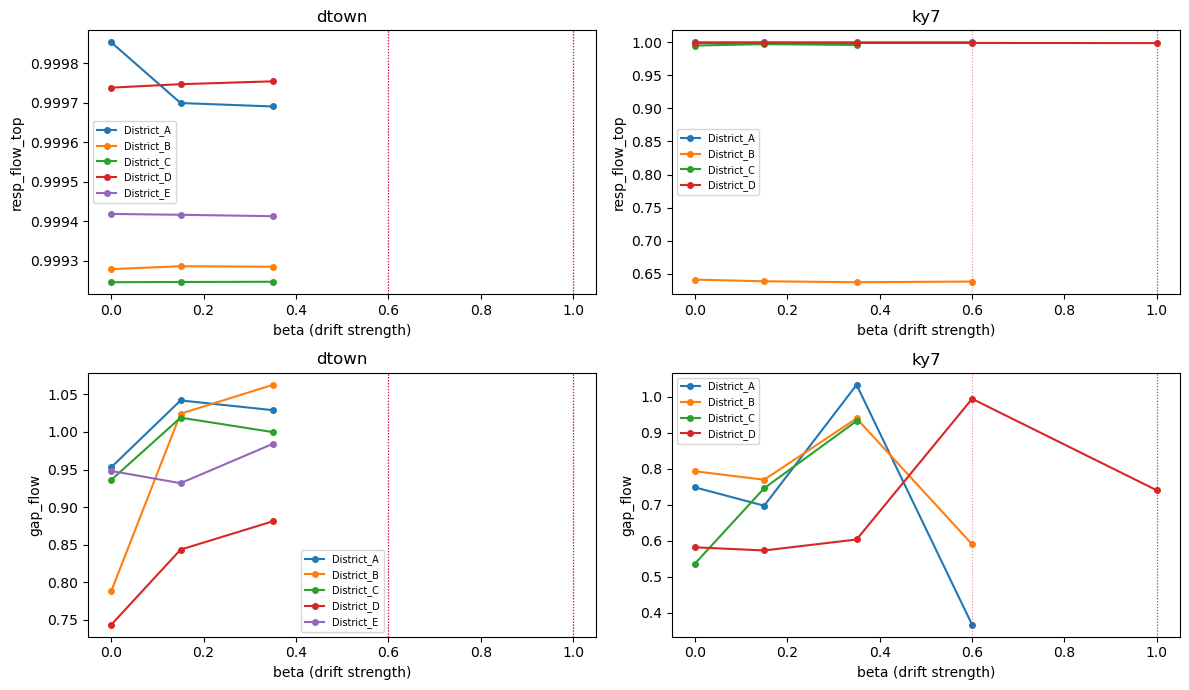

In [5]:
L = ls.beta_ladder(CELLS)
display(L.round(3))
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
ls.plot_beta_ladder(CELLS, "resp_flow_top", axes=axes[0])
ls.plot_beta_ladder(CELLS, "gap_flow", axes=axes[1])
plt.tight_layout(); plt.show()

In [6]:
display(ls.beta_threshold(CELLS, "resp_flow_top", 0.5))
display(ls.beta_threshold(CELLS, "resp_pressure_top", 0.3))

,network,drift_district,cells_ok,min_beta[resp_flow_top>=0.5]
0,dtown,District_A,3,0.0
1,dtown,District_B,3,0.0
2,dtown,District_C,3,0.0
3,dtown,District_D,3,0.0
4,dtown,District_E,3,0.0
5,ky7,District_A,4,0.0
6,ky7,District_B,4,0.0
7,ky7,District_C,3,0.0
8,ky7,District_D,5,0.0


,network,drift_district,cells_ok,min_beta[resp_pressure_top>=0.3]
0,dtown,District_A,3,0.0
1,dtown,District_B,3,0.0
2,dtown,District_C,3,0.0
3,dtown,District_D,3,0.0
4,dtown,District_E,3,0.0
5,ky7,District_A,4,0.0
6,ky7,District_B,4,0.0
7,ky7,District_C,3,0.0
8,ky7,District_D,5,NaN


Two controls worth checking against the ladder before reading it as a result.

`shape_shift` at `beta = 0` should already be large — it is the drift-induced change in the
district's own demand profile, before any hydraulics. If it is small, the sector signatures
are too close and the problem is upstream of the sensors.

`d_demand_%` at `beta = 0` should be ~0. If it is not, beta is not doing what the level
model says and the ladder is confounded.

,network,drift_district,d_demand_%,shape_shift,resp_flow_top,resp_pressure_top,gap_flow
0,ky7,District_A,0.782,0.720,1.000,0.738,0.749
5,ky7,District_B,0.528,0.709,0.641,0.346,0.793
10,ky7,District_C,0.027,0.590,0.995,0.533,0.537
15,ky7,District_D,-0.348,0.727,0.999,0.175,0.582
20,dtown,District_A,0.254,0.724,1.000,0.989,0.953
25,dtown,District_B,-0.213,0.725,0.999,0.385,0.788
30,dtown,District_C,-0.441,0.727,0.999,0.466,0.936
35,dtown,District_D,0.433,0.734,1.000,0.514,0.743
40,dtown,District_E,-0.023,0.725,0.999,0.862,0.948


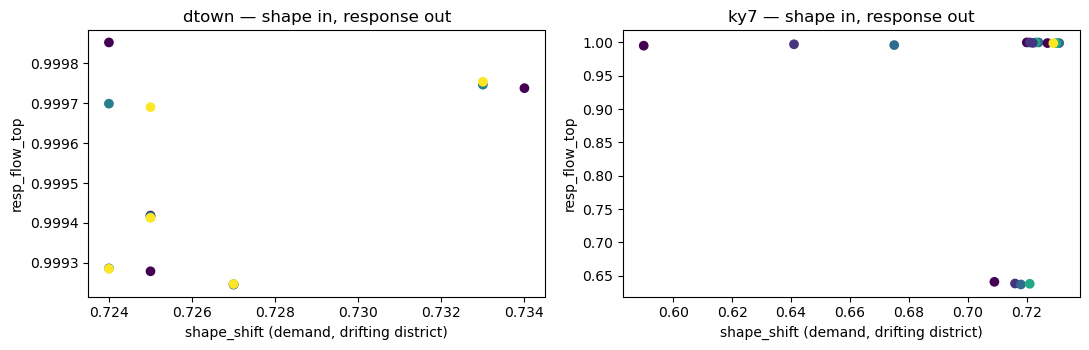

In [7]:
base = CELLS[(CELLS["beta"] == 0.0) & (CELLS["status"] == "ok")]
display(base[["network", "drift_district", "d_demand_%", "shape_shift",
              "resp_flow_top", "resp_pressure_top", "gap_flow"]].round(3))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for a, net in zip(ax, sorted(CELLS["network"].unique())):
    d = CELLS[(CELLS["network"] == net) & (CELLS["status"] == "ok")]
    a.scatter(d["shape_shift"], d["resp_flow_top"], c=d["beta"], cmap="viridis", s=36)
    a.set(xlabel="shape_shift (demand, drifting district)",
          ylabel="resp_flow_top", title=f"{net} — shape in, response out")
plt.tight_layout(); plt.show()

## 4. The leak — how much response lands outside the drifting district

Rows: which district drifted. Columns: where the response was measured, using each
district's three best-resembling flow gauges. The diagonal is signal, everything off it is
hydraulic contamination.

On a closed network the off-diagonal cannot be zero. The ratio of diagonal to off-diagonal
is the de-confounding problem stated in numbers, per network — and the expectation from the
Graeme work is that D-Town's decoupled districts give a much cleaner diagonal than KY7,
where everything floats on three shared tanks.

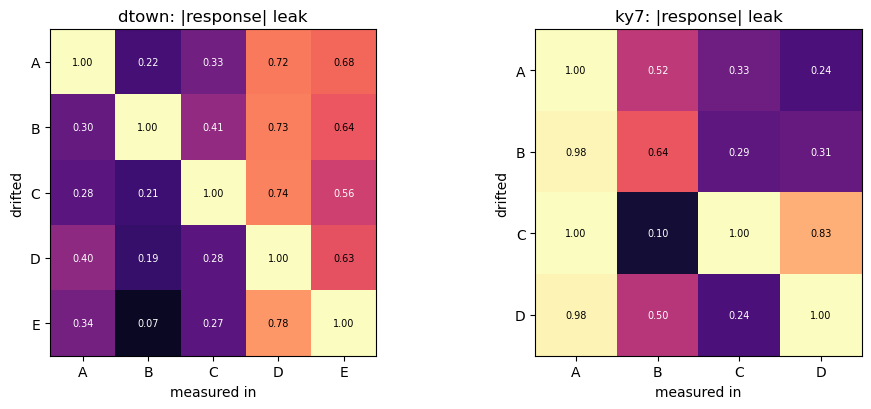

dtown: diagonal 0.999 | off-diagonal 0.440 | ratio 2.3x
ky7: diagonal 0.908 | off-diagonal 0.526 | ratio 1.7x


In [8]:
M = ls.leak_matrix(SCORES, phase="final", kind="flow", top=3)
fig, axes = plt.subplots(1, len(M), figsize=(5.0 * len(M), 4.2))
ls.plot_leak(M, axes=np.atleast_1d(axes))
plt.tight_layout(); plt.show()

for net, A in M.items():
    diag = np.diag(A.to_numpy())
    off = A.to_numpy()[~np.eye(len(A), dtype=bool)]
    print(f"{net}: diagonal {diag.mean():.3f} | off-diagonal {off.mean():.3f} "
          f"| ratio {diag.mean() / max(off.mean(), 1e-9):.1f}x")

In [9]:
# Same thing on pressure. If the pressure leak ratio is near 1, a pressure gauge cannot
# tell its own district's drift from a neighbour's — which is the specific failure mode
# that makes pressure useless for attribution, distinct from it being noisy.
Mp = ls.leak_matrix(SCORES, phase="final", kind="pressure", top=3)
for net, A in Mp.items():
    diag = np.diag(A.to_numpy())
    off = A.to_numpy()[~np.eye(len(A), dtype=bool)]
    print(f"{net} pressure: diag {diag.mean():.3f} | off {off.mean():.3f} "
          f"| ratio {diag.mean() / max(off.mean(), 1e-9):.1f}x")
display(Mp["dtown"].round(3) if "dtown" in Mp else Mp)

dtown pressure: diag 0.745 | off 0.194 | ratio 3.8x
ky7 pressure: diag 0.290 | off 0.125 | ratio 2.3x


,District_A,District_B,District_C,District_D,District_E
District_A,0.989,0.313,0.079,0.093,0.074
District_B,0.490,0.686,0.079,0.107,0.152
District_C,0.442,0.156,0.572,0.111,0.086
District_D,0.419,0.303,0.046,0.568,0.080
District_E,0.436,0.295,0.067,0.063,0.908


## 5. (a) Which gauges carry the signal

**Resemblance carriers** are scored in the drift-free `init` phase and averaged across every
cell in the grid, so they are a property of the network and the placement rather than of any
one drift. `r_std` is the stability, and `share` in the next table is how often the gauge
landed in its district's top 5 across all cells — near 1.0 means placement can be decided
once and reused.

,network,district,kind,id,role,r_mean,r_std,r_min,count,rank
0,dtown,District_A,flow,q_P1024,internal,0.828,0.0,0.828,15,1.0
1,dtown,District_A,flow,q_P1023,internal,0.826,0.0,0.826,15,2.0
2,dtown,District_A,flow,q_P956,internal,0.744,0.0,0.744,15,3.0
3,dtown,District_A,flow,q_P955,internal,0.743,0.0,0.743,15,4.0
4,dtown,District_A,flow,q_v1,internal,0.714,0.0,0.714,15,5.0
10,dtown,District_B,flow,q_P46,internal,0.653,0.0,0.653,15,1.0
11,dtown,District_B,flow,q_P866,internal,0.605,0.0,0.605,15,2.0
12,dtown,District_B,flow,q_P51,internal,0.604,0.0,0.604,15,3.0
13,dtown,District_B,flow,q_P858,internal,0.491,0.0,0.491,15,4.0
14,dtown,District_B,flow,q_P633,internal,0.411,0.0,0.411,15,5.0


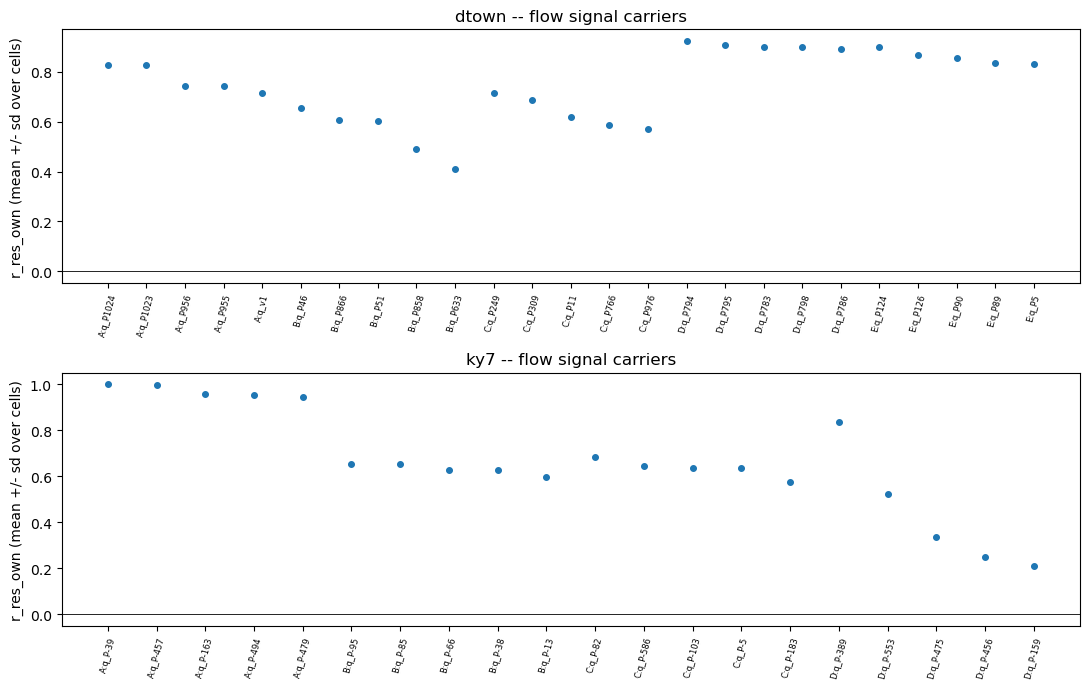

gauges with share >= 0.8
network kind                              
dtown   flow                            25
        pressure                        25
ky7     flow                            20
        pressure                        20

In [10]:
CAR = ls.signal_carriers(SCORES, phase="init", top=5)
STAB = ls.stability(SCORES, phase="init", top=5)
display(CAR[CAR["kind"] == "flow"].round(3))

fig, axes = plt.subplots(2, 1, figsize=(11, 7))
for ax, net in zip(axes, sorted(SCORES["network"].unique())):
    ls.plot_carriers(CAR, net, "flow", ax=ax)
plt.tight_layout(); plt.show()

display(STAB[STAB["share"] >= 0.8].groupby(["network", "kind"]).size()
        .rename("gauges with share >= 0.8").to_frame())

**Response carriers** are the stricter test: restricted to the cells where this gauge's own
district is the drifting one, ranked by response rather than resemblance. `beta_min` is the
smallest strength at which that gauge already responded above 0.5 — the per-gauge version of
the ladder.

In [11]:
DRF = ls.drift_carriers(SCORES, phase="final", top=5)
display(DRF[DRF["kind"] == "flow"].round(3))
display(DRF[DRF["kind"] == "pressure"].round(3))

,network,district,kind,id,role,resp_mean,resp_std,r_mean,n,beta_min,rank
0,dtown,District_A,flow,q_P937,internal,1.000,0.000,1.000,3,0.0,1.0
1,dtown,District_A,flow,q_P951,internal,1.000,0.000,1.000,3,0.0,2.0
2,dtown,District_A,flow,q_P938,internal,1.000,0.000,1.000,3,0.0,3.0
3,dtown,District_A,flow,q_1,internal,1.000,0.000,1.000,3,0.0,4.0
4,dtown,District_A,flow,q_P953,internal,1.000,0.000,1.000,3,0.0,5.0
10,dtown,District_B,flow,q_P633,internal,1.000,0.000,1.000,3,0.0,1.0
11,dtown,District_B,flow,q_P51,internal,0.999,0.000,1.000,3,0.0,2.0
12,dtown,District_B,flow,q_P42,internal,0.999,0.000,1.000,3,0.0,3.0
13,dtown,District_B,flow,q_P48,internal,0.999,0.000,1.000,3,0.0,4.0
14,dtown,District_B,flow,q_P859,internal,0.999,0.000,1.000,3,0.0,5.0


,network,district,kind,id,role,resp_mean,resp_std,r_mean,n,beta_min,rank
5,dtown,District_A,pressure,p_J81,internal,0.989,0.000,0.999,3,0.00,1.0
6,dtown,District_A,pressure,p_J34,internal,0.989,0.000,0.999,3,0.00,2.0
7,dtown,District_A,pressure,p_J33,internal,0.989,0.000,0.999,3,0.00,3.0
8,dtown,District_A,pressure,p_J38,internal,0.989,0.000,0.999,3,0.00,4.0
9,dtown,District_A,pressure,p_J36,internal,0.989,0.000,0.999,3,0.00,5.0
15,dtown,District_B,pressure,p_J76,internal,0.689,0.262,0.487,3,0.15,1.0
16,dtown,District_B,pressure,p_J92,internal,0.688,0.261,0.485,3,0.15,2.0
17,dtown,District_B,pressure,p_J70,internal,0.679,0.258,0.469,3,0.15,3.0
18,dtown,District_B,pressure,p_J69,internal,0.679,0.258,0.469,3,0.15,4.0
19,dtown,District_B,pressure,p_J61,internal,0.677,0.257,0.466,3,0.15,5.0


In [12]:
# Do the two rankings agree? A gauge that resembles but does not respond is dominated by
# transit flow: the district's water passes through it, so it looks like the district and
# does not move when the district's behaviour changes.
J = (CAR.merge(DRF[["network", "district", "kind", "id", "resp_mean", "beta_min"]],
               on=["network", "district", "kind", "id"], how="outer", indicator=True))
print(J["_merge"].value_counts().to_string())
display(J[J["_merge"] == "both"][["network", "district", "kind", "id", "r_mean",
                                  "resp_mean", "beta_min"]].round(3))

_merge
left_only     58
right_only    58
both          32


,network,district,kind,id,r_mean,resp_mean,beta_min
12,dtown,District_A,pressure,p_J33,0.201,0.989,0.00
14,dtown,District_A,pressure,p_J36,0.201,0.989,0.00
15,dtown,District_A,pressure,p_J38,0.201,0.989,0.00
20,dtown,District_B,flow,q_P51,0.604,0.999,0.00
21,dtown,District_B,flow,q_P633,0.411,1.000,0.00
41,dtown,District_C,flow,q_P976,0.570,1.000,0.00
48,dtown,District_C,pressure,p_J297,0.018,0.563,0.15
54,dtown,District_D,flow,q_P783,0.900,1.000,0.00
55,dtown,District_D,flow,q_P786,0.892,1.000,0.00
56,dtown,District_D,flow,q_P794,0.925,1.000,0.00


## 6. A placement chosen on the whole grid

Ranked by mean resemblance across every cell and tie-broken by stability, so the result is
the placement that holds whatever drifts next — rather than the one that happened to win in
a single world.

In [13]:
for net in sorted(SCORES["network"].unique()):
    prop = ls.proposed_sensors(SCORES, net, n_pressure=2, n_flow=3, phase="init")
    print(f"# ---- {net} ----")
    print(sp.sensors_yaml(prop), "\n")

# ---- dtown ----
sensors:
  District_A: {pressure: ["J182", "J150"], flow: ["P1024", "P1023", "P956"]}
  District_B: {pressure: ["J246", "J236"], flow: ["P46", "P866", "P51"]}
  District_C: {pressure: ["J297", "J221"], flow: ["P249", "P309", "P11"]}
  District_D: {pressure: ["J158", "J157"], flow: ["P794", "P795", "P783"]}
  District_E: {pressure: ["J332", "J201"], flow: ["P124", "P126", "P90"]} 

# ---- ky7 ----
sensors:
  District_A: {pressure: ["J-95", "J-151"], flow: ["P-39", "P-457", "P-163"]}
  District_B: {pressure: ["J-9", "J-14"], flow: ["P-95", "P-85", "P-66"]}
  District_C: {pressure: ["J-413", "J-8"], flow: ["P-82", "P-586", "P-103"]}
  District_D: {pressure: ["J-215", "J-207"], flow: ["P-389", "P-553", "P-475"]} 



In [14]:
# The shipped placement, scored on the same grid. `pct` is where each shipped gauge sits in
# its own (district, kind) ranking, averaged over cells.
d = SCORES[SCORES["phase"] == "init"].copy()
d["pct"] = d.groupby(["network", "sim_hash", "district", "kind"])["r_res_own"].rank(pct=True)
ship = (d[d["shipped"]].groupby(["network", "district", "kind", "id"])
        [["r_res_own", "pct", "response"]].mean().reset_index().round(3))
display(ship.sort_values(["network", "district", "kind"]))
print(ship.groupby(["network", "kind"])["pct"].mean().round(3).to_string())

,network,district,kind,id,r_res_own,pct,response
0,dtown,District_A,flow,q_P1036,0.573,0.904,0.432
1,dtown,District_A,flow,q_P349,0.024,0.222,-0.002
2,dtown,District_A,flow,q_P958,0.080,0.519,0.010
3,dtown,District_A,pressure,p_J32,0.181,0.914,0.632
4,dtown,District_A,pressure,p_J497,-0.086,0.118,0.084
5,dtown,District_B,flow,q_P1044,-0.065,0.130,-0.102
6,dtown,District_B,flow,q_P245,-0.055,0.500,0.051
7,dtown,District_B,flow,q_P842,-0.063,0.278,-0.073
8,dtown,District_B,pressure,p_J67,0.045,0.093,0.280
9,dtown,District_B,pressure,p_J87,0.057,0.465,0.008


network  kind    
dtown    flow        0.420
         pressure    0.371
ky7      flow        0.565
         pressure    0.812


## 7. Read-out

**(a) Sensors.** §5 gives the two lists per network. Commit to a gauge only if it appears in
both — high `r_mean` with high `share` in the resemblance table, and high `resp_mean` with a
low `beta_min` in the response table. §6 turns that into a `sensors:` block; §6's second
cell says how much the shipped rule was leaving on the table.

**(b) Does the drift engine need work.** The decision is `beta_threshold` in §3. If
`min_beta[resp_flow_top>=0.5]` is 0.0 for most districts on both networks, the sector shape
signature carries the drift on its own and the consumption-attribution protocol is fine —
the remaining problem is placement and coupling, not the demand model. If it is 0.6 or 1.0,
or NaN, then detection depends on a level change of 4x–9x that D-Town's hydraulic envelope
may not even permit, and the protocol needs a stronger *shape* contrast: wider sector
separation, a night-floor or weekend gate that survives mixing, or a land-use mix that is
less residential-dominated by volume.

**Which districts are hopeless, and why.** A district with a flat ladder at every beta is
either badly metered (fix in §6) or hydraulically buried. Cross-check its row in the §4 leak
matrix against its `served_own` and its position in the supply chain: if its own gauges
respond no more than its neighbours' do, no placement fixes it and the district is a
candidate for exclusion rather than for a better sensor.

**Pressure.** If the pressure leak ratio in §4 is near 1 on both networks, pressure cannot
attribute a drift to a district even when it detects one, and pressure channels should be
dropped from the FL feature set rather than carried as noise.

### Next
Fix the placement from §6 into each bundle's `profile.yml`, regenerate the worlds, and only
then run FL. Training on the shipped placement would confound "the method cannot recover
regimes" with "the gauges never saw them".